In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from typing import TypedDict

/Users/himanibhardwaj/himcodes/GenAI/LangGraph-Project/.venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
model = ChatOllama(model='gemma3:270m')

In [3]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [4]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [5]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [ ]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()

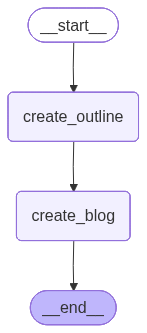

In [12]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [7]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state['outline'])

Here's a detailed outline for a blog post on the rise of AI in India:

**Blog Title:** Rise of AI in India: Transforming Industries, Society, and the Future

**Target Audience:** Business professionals, policymakers, students, and anyone interested in understanding the impact of AI in India.

**Blog Goal:** To provide a comprehensive overview of the current state of AI in India, its potential benefits, challenges, and future outlook, while also addressing key trends and challenges.

**I. Introduction (Hook & Overview)**

*   **A. Introduction:**
    *   Start with a compelling statistic or anecdote about AI adoption in India, highlighting its rapid growth and impact.
    *   Briefly introduce the topic of AI in India and its significance.
    *   State the blog's purpose: to provide a detailed and informative overview of the current state of AI in India.
    *   Highlight the key aspects of AI in India: its potential to drive economic growth, improve efficiency, create new opportunitie

In [8]:
print(final_state['content'])

**Blog Title:** Rise of AI in India: Transforming Industries, Society, and the Future

**Target Audience:** Business professionals, policymakers, students, and anyone interested in understanding the impact of AI in India.

**Blog Goal:** To provide a comprehensive overview of the current state of AI in India, its potential benefits, challenges, and future outlook, while also addressing key trends and challenges.

**I. Introduction (Hook & Overview)**

*   **A. Introduction:**
    *   Start with a compelling statistic or anecdote about AI adoption in India, highlighting its rapid growth and impact.
    *   Briefly introduce the topic of AI in India and its significance.
    *   State the blog's purpose: to provide a detailed and informative overview of the current state of AI in India.
    *   Highlight the key aspects of AI in India: its potential to drive economic growth, improve efficiency, create new opportunities, and address societal challenges.
    *   Briefly outline the blog's 